In [1]:
import os
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import ast

In [2]:
os.chdir(os.path.join(os.getcwd(), '..'))

In [3]:
os.getcwd()

'd:\\learning\\learning\\programing\\portfolio_projects\\1_image'

In [4]:
from src.entity.config_entity import ImagePrepEntity

In [5]:
ent = ImagePrepEntity()
df =  pd.read_csv(ent.processed_metadata_file)

In [6]:
df.head()

,collapsed_id,case,slice,height,width,empty_slice,path,prev_path,next_path,large_bowel,small_bowel,stomach
0,0,2,1,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN
1,0,2,2,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN
2,0,2,3,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN
3,0,2,4,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN
4,0,2,5,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN


In [6]:
from src.utils import *

In [8]:
img = Image.open(df['path'].iloc[62])

In [9]:
img_16 = cv2.imread(df['path'].iloc[62], cv2.IMREAD_UNCHANGED)
img_norm = cv2.normalize(img_16, None, alpha=0, beta = 255, norm_type=cv2.NORM_MINMAX)
img_8 = img_norm.astype(np.uint8)
img_8.shape

(266, 266)

In [10]:
mask = make_img_mask(df['large_bowel'].iloc[62], df['small_bowel'].iloc[62], df['stomach'].iloc[62], df['height'].iloc[62], df['width'].iloc[62])
mask.shape

(3, 266, 266)

In [11]:
type(mask[0,0,0])

numpy.bool

In [12]:
img_256 = np.resize(img_8, (256, 256))

In [14]:
colour_img = np.stack([img_256, img_256, img_256], axis=-1)
colour_img[mask_256[0] == 1] = [255, 0, 0]
colour_img[mask_256[1] == 1] = [0, 255, 0]
colour_img[mask_256[2] == 1] = [0, 0, 255]

In [13]:
colour_img_ = np.stack([img_8, img_8, img_8], axis=-1)
colour_img_[mask[0] == 1] = [255, 0, 0]
colour_img_[mask[1] == 1] = [0, 255, 0]
colour_img_[mask[2] == 1] = [0, 0, 255]

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

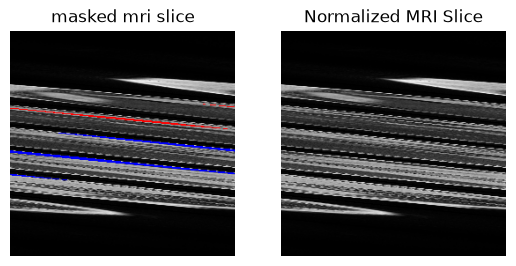

In [15]:
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.imshow(colour_img)
plt.title("masked mri slice")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_256, cmap = 'gray')
plt.title("Normalized MRI Slice")
plt.axis('off')

(np.float64(-0.5), np.float64(265.5), np.float64(265.5), np.float64(-0.5))

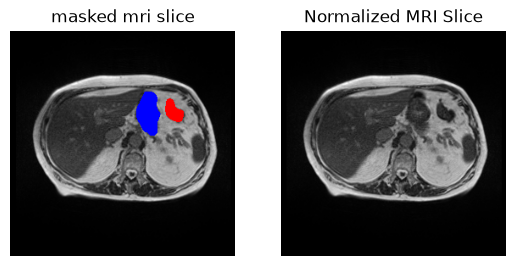

In [15]:
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.imshow(colour_img_)
plt.title("masked mri slice")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_8, cmap = 'gray')
plt.title("Normalized MRI Slice")
plt.axis('off')

In [16]:
def show_mask_img(orig_img_arr, mask_arr, alpha = 0.5):
    img_norm = orig_img_arr.astype(float)
    if np.max(img_norm) > 1.0:
        img_norm = img_norm / 255.0

    # Create a 3-channel RGB image
    colour_img = np.stack([img_norm, img_norm, img_norm], axis=-1)
    colour_img[mask_arr[0] == 1] = colour_img[mask_arr[0] == 1] * (1 - alpha) + np.array([1, 0, 0]) * alpha
    colour_img[mask_arr[1] == 1] = colour_img[mask_arr[1] == 1] * (1 - alpha) + np.array([0, 1, 0]) * alpha 
    colour_img[mask_arr[2] == 1] = colour_img[mask_arr[2] == 1] * (1 - alpha) + np.array([0, 0, 1]) * alpha

    plt.subplot(1, 2, 1)
    plt.imshow(colour_img)
    plt.title("masked mri slice")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(orig_img_arr, cmap = 'gray')
    plt.title("Normalized MRI Slice")
    plt.axis('off')

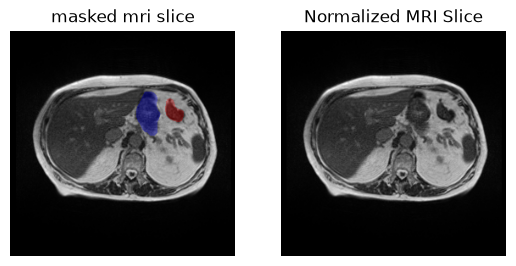

In [16]:
show_mask_img(img_8, mask, 0.3)

In [7]:
df['mask_path'] = df.apply(lambda n: Path(ent.out_mask_dir, f'{n['collapsed_id']}_{n['case']}_{n['slice']}.npy' ), axis = 1)

In [18]:
df.head()

,collapsed_id,case,slice,height,width,empty_slice,path,prev_path,next_path,large_bowel,small_bowel,stomach,mask_path
0,0,2,1,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN,data\preprocessed_data\final_data\output_mask\...
1,0,2,2,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN,data\preprocessed_data\final_data\output_mask\...
2,0,2,3,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN,data\preprocessed_data\final_data\output_mask\...
3,0,2,4,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN,data\preprocessed_data\final_data\output_mask\...
4,0,2,5,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN,data\preprocessed_data\final_data\output_mask\...


In [19]:
df['mask_path'].iloc[0]

WindowsPath('data/preprocessed_data/final_data/output_mask/0_2_1.npy')

In [20]:
os.makedirs(ent.out_mask_dir, exist_ok= True)



In [24]:
i = 0
for row in df.itertuples(index = True):
    mask = make_img_mask(row.large_bowel, row.small_bowel, row.stomach, row.height, row.width)
    if i == 0:
        print(f'mask shape: {mask.shape}')
        print(f'mask element type: {type(mask[0,0,0])}')
        print(f'mask size: {np.size(mask)}')
        
    np.save(row.mask_path, mask)
    

mask shape: (3, 266, 266)
mask element type: <class 'numpy.bool'>
mask size: 212268
mask shape: (3, 266, 266)
mask element type: <class 'numpy.bool'>
mask size: 212268
mask shape: (3, 266, 266)
mask element type: <class 'numpy.bool'>
mask size: 212268
mask shape: (3, 266, 266)
mask element type: <class 'numpy.bool'>
mask size: 212268
mask shape: (3, 266, 266)
mask element type: <class 'numpy.bool'>
mask size: 212268
mask shape: (3, 266, 266)
mask element type: <class 'numpy.bool'>
mask size: 212268
mask shape: (3, 266, 266)
mask element type: <class 'numpy.bool'>
mask size: 212268
mask shape: (3, 266, 266)
mask element type: <class 'numpy.bool'>
mask size: 212268
mask shape: (3, 266, 266)
mask element type: <class 'numpy.bool'>
mask size: 212268
mask shape: (3, 266, 266)
mask element type: <class 'numpy.bool'>
mask size: 212268
mask shape: (3, 266, 266)
mask element type: <class 'numpy.bool'>
mask size: 212268
mask shape: (3, 266, 266)
mask element type: <class 'numpy.bool'>
mask size:

In [26]:
i = 0
for _ in ent.out_mask_dir.iterdir():
    i+=1
print(i)

38496


In [28]:
df[df.large_bowel.notna()]

,collapsed_id,case,slice,height,width,empty_slice,path,prev_path,next_path,large_bowel,small_bowel,stomach,mask_path
58,0,2,59,266,266,False,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,24931 2 25195 5 25461 5 25726 7 25992 7 26259 ...,NaN,22772 6 23035 10 23300 12 23564 15 23830 16 24...,data\preprocessed_data\final_data\output_mask\...
59,0,2,60,266,266,False,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,24396 5 24661 8 24926 10 25192 10 25458 11 257...,NaN,22238 5 22503 9 22769 10 23034 13 23298 16 235...,data\preprocessed_data\final_data\output_mask\...
60,0,2,61,266,266,False,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,24131 2 24395 6 24660 8 24926 9 25192 10 25457...,NaN,22236 10 22500 13 22765 15 23031 16 23296 18 2...,data\preprocessed_data\final_data\output_mask\...
61,0,2,62,266,266,False,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,23067 2 23331 6 23596 8 23861 10 24127 11 2439...,NaN,19579 8 19844 10 20109 12 20374 13 20640 14 20...,data\preprocessed_data\final_data\output_mask\...
62,0,2,63,266,266,False,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,21468 3 21732 7 21998 8 22263 9 22529 10 22795...,NaN,19312 9 19577 12 19843 13 20108 15 20374 16 20...,data\preprocessed_data\final_data\output_mask\...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38471,273,156,120,266,266,False,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,20106 9 20370 14 20635 18 20885 2 20901 19 211...,24119 3 24383 8 24648 15 24913 19 25108 2 2517...,NaN,data\preprocessed_data\final_data\output_mask\...
38472,273,156,121,266,266,False,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,20106 10 20370 14 20616 6 20635 17 20869 4 208...,24116 7 24312 2 24380 11 24400 3 24576 6 24645...,NaN,data\preprocessed_data\final_data\output_mask\...
38473,273,156,122,266,266,False,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,19842 6 20105 11 20349 6 20369 15 20608 15 206...,23850 5 24045 6 24114 9 24310 8 24379 11 24399...,NaN,data\preprocessed_data\final_data\output_mask\...
38474,273,156,123,266,266,False,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,20102 13 20352 30 20608 42 20871 46 21135 48 2...,23250 4 23514 7 23779 8 23849 5 24044 10 24113...,NaN,data\preprocessed_data\final_data\output_mask\...


In [33]:
mask_path = df.iloc[38475]['mask_path']
loaded_mask = np.load(mask_path)
img_16 = cv2.imread(df['path'].iloc[38475], cv2.IMREAD_UNCHANGED)
img_norm = cv2.normalize(img_16, None, alpha=0, beta = 255, norm_type=cv2.NORM_MINMAX)
img_8 = img_norm.astype(np.uint8)


In [30]:
loaded_mask

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

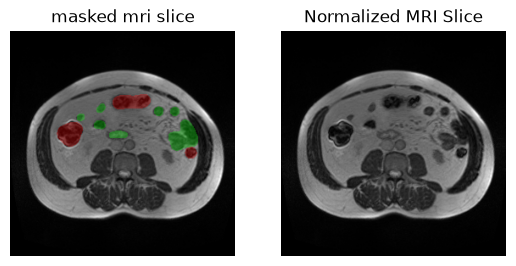

In [34]:
show_mask_img(img_8, loaded_mask, 0.3)

In [19]:
q = df.case.unique()
rng = np.random.default_rng(seed = 42)
g = rng.choice(q, 5)
g


array([ 18, 130, 116,  80,  78])

In [24]:
test_df = df[df['case'].isin(g)]

In [21]:
len(df.case.unique())

85

In [29]:
q = df.case.unique()

len([n for n in q if n not in g])

80

In [22]:
df.head()

,collapsed_id,case,slice,height,width,empty_slice,path,prev_path,next_path,large_bowel,small_bowel,stomach,mask_path
0,0,2,1,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN,data\preprocessed_data\final_data\output_mask\...
1,0,2,2,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN,data\preprocessed_data\final_data\output_mask\...
2,0,2,3,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN,data\preprocessed_data\final_data\output_mask\...
3,0,2,4,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN,data\preprocessed_data\final_data\output_mask\...
4,0,2,5,266,266,True,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,NaN,NaN,NaN,data\preprocessed_data\final_data\output_mask\...


In [27]:
train_df = df[df.case.isin(g)].reset_index(drop = True)

In [37]:
cols = train_df.columns

expr = [c in cols for c in cols]
np.prod(expr)

np.int64(1)

In [30]:
ent.train_map_file.parent

WindowsPath('data/preprocessed_data/final_data')

In [ ]:
ent.out_mask_dir.

In [1]:
cases = [1,4,5,6,8]
chousen_cases = [5,6,8]

In [2]:
[c for c in cases if c not in chousen_cases]

[1, 4]